In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\uktiw\Downloads\Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Replacing Blanks with 0 as tenure is 0 and no total charges are recorder**

In [7]:
df['TotalCharges']= df['TotalCharges'].replace(" ", "0")
df['TotalCharges']= df['TotalCharges'].astype("float")

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

***No null Values***

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df['customerID'].duplicated().sum()

np.int64(0)

***No Duplicate Values in unique columns***

In [14]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
df['SeniorCitizen']= df['SeniorCitizen'].apply(conv)

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 ***Converting 0 and 1 of Senior Citizen values to Yes/No to make it easier to understand.***


C:\Users\uktiw\AppData\Local\Temp\ipykernel_6296\3390296430.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot( x= 'Churn' , data = df , palette = 'Set1')


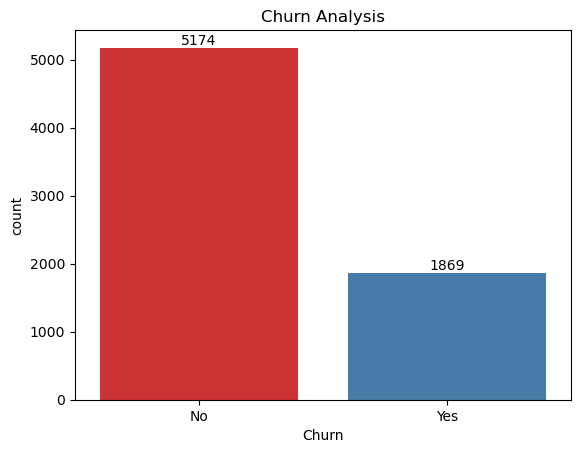

In [27]:
ax = sns.countplot( x= 'Churn' , data = df , palette = 'Set1')
plt.title('Churn Analysis')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

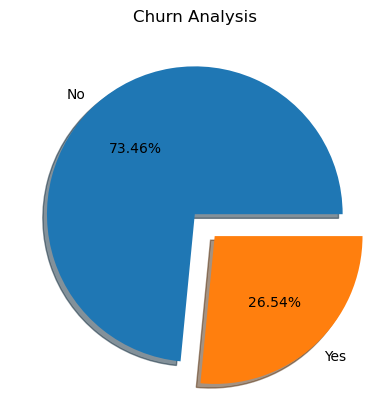

In [29]:
gb= df.groupby("Churn").agg({'Churn':"count"})
explode = (0,0.2)
plt.pie(gb['Churn'], labels= gb.index, autopct = "%1.2f%%", shadow= True, explode= explode)
plt.title('Churn Analysis')
plt.show()

*From the Given pie chart we can conclude that 26.54% of our customer have churned out.--- Lets Find out the Reason*

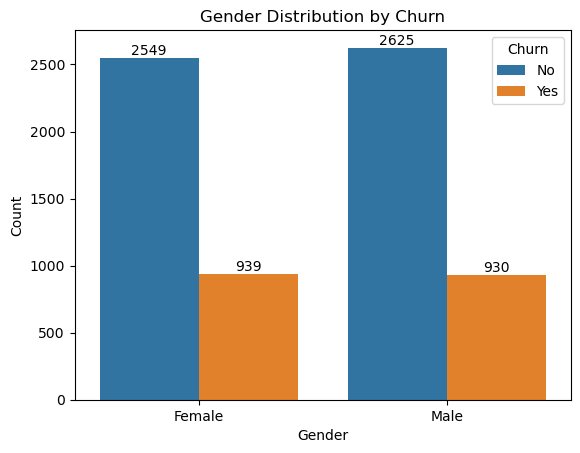

In [35]:
ax= sns.countplot(x = 'gender', data= df, hue= 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Gender Distribution by Churn")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**With this data we know that Males are More in Volume and Female has high Churn Rate**

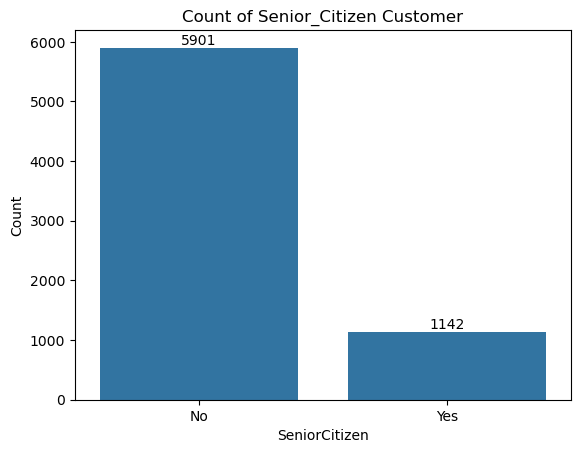

In [40]:
ax= sns.countplot(x = 'SeniorCitizen', data= df)
ax.bar_label(ax.containers[0])
plt.title("Count of Senior_Citizen Customer")
plt.xlabel("SeniorCitizen")
plt.ylabel("Count")
plt.show()

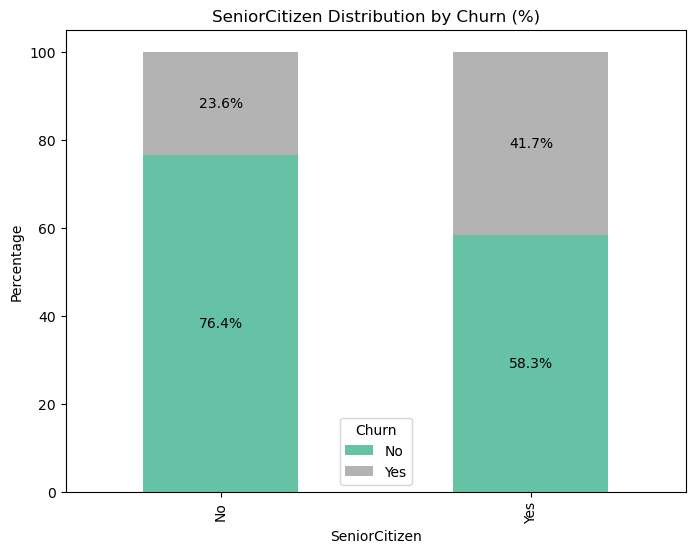

In [38]:
# Create crosstab of SeniorCitizen vs Churn
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
# Convert counts to percentages row-wise
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
# Plot stacked bar chart
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')
# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title("SeniorCitizen Distribution by Churn (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

**Senior citizens show a markedly higher churn risk, with 41.7% leaving compared to 23.6% among non‑seniors.**

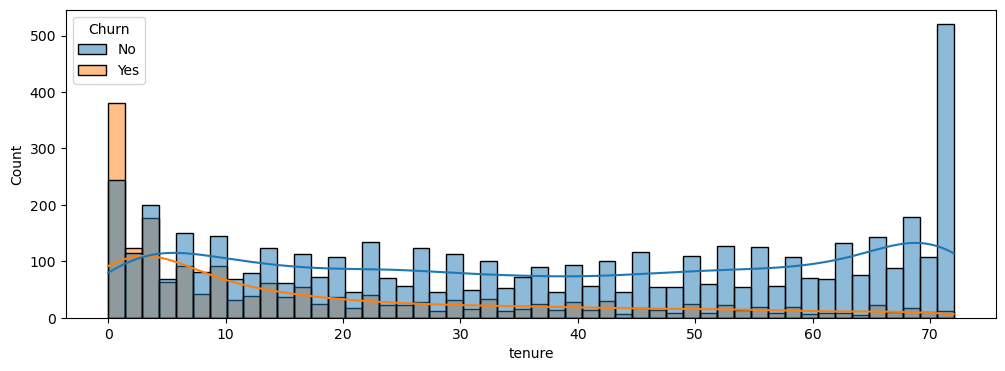

In [46]:
plt.figure(figsize= (12,4))
sns.histplot(x= 'tenure', data= df,bins= 50, kde= True, hue= 'Churn')
plt.show()

**People Who have used our services from long time  have Stayed and people who have used our services for 1 or 2 months have churned out**

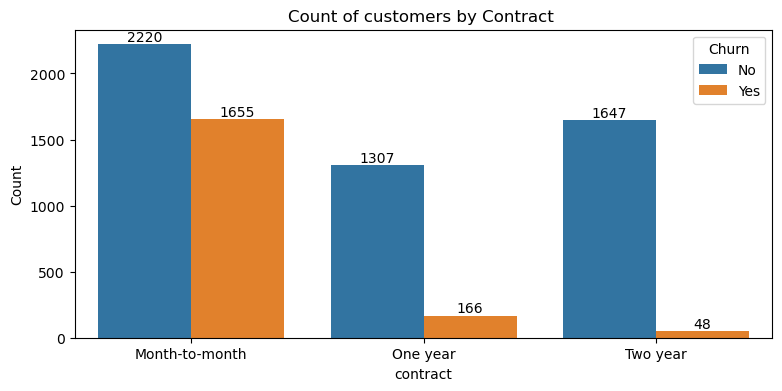

In [51]:
plt.figure(figsize= (9,4))
ax= sns.countplot(x = 'Contract',hue= 'Churn', data= df)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Count of customers by Contract ")
plt.xlabel("contract")
plt.ylabel("Count")
plt.show()

**People who have Month-to-Month Contract are likely to churn then from those who have 1 or 2 year old contract**

In [56]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

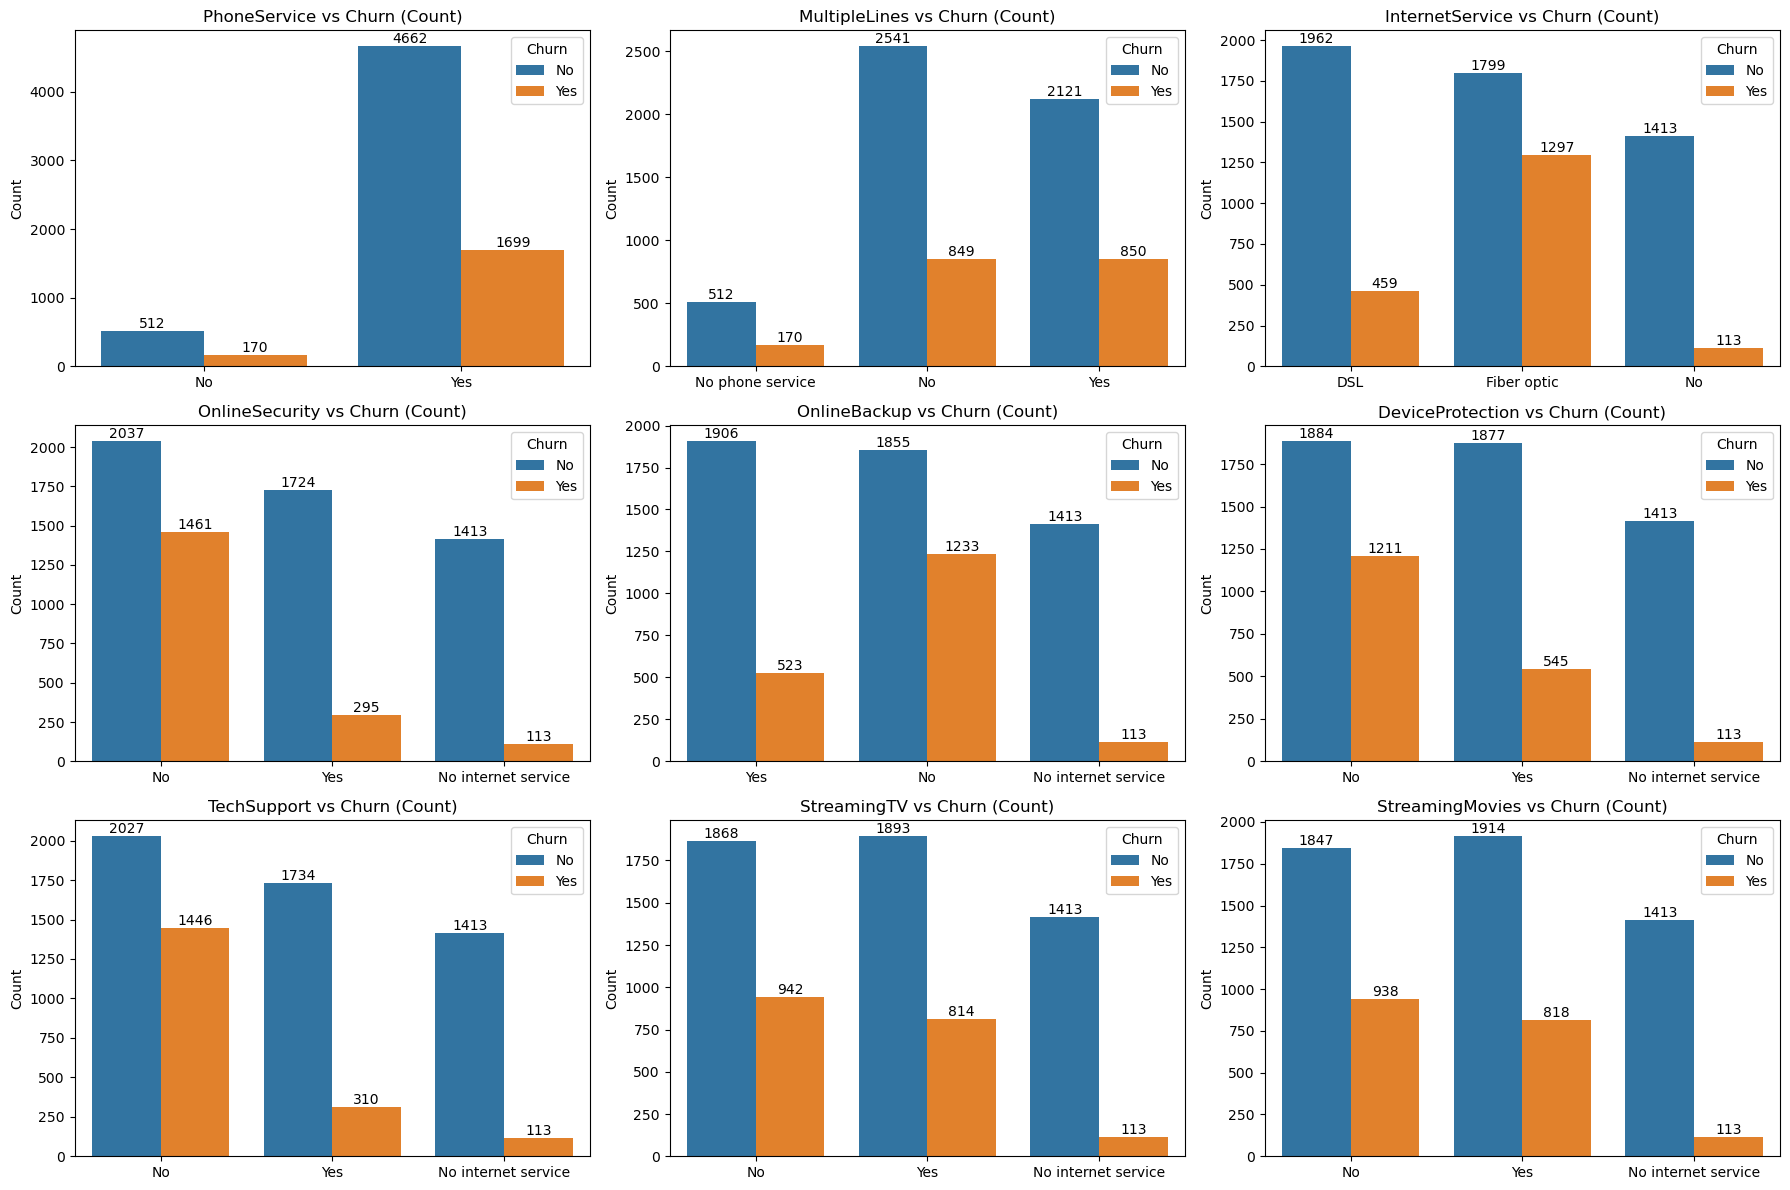

In [59]:
cols = ['PhoneService','MultipleLines','InternetService',
        'OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies']
fig, axes = plt.subplots(3, 3, figsize=(18,12))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    axes[i].set_title(f"{col} vs Churn (Count)")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

***The churn analysis shows clear service‑linked patterns. Customers without added services like **TechSupport** or **OnlineSecurity** churn at much higher rates, while those with these features are more likely to stay. Fiber optic internet users show the highest churn compared to DSL or no internet service. Streaming services (TV and Movies) display moderate churn differences, but overall, lack of support and protection services is the strongest driver of customer attrition.***

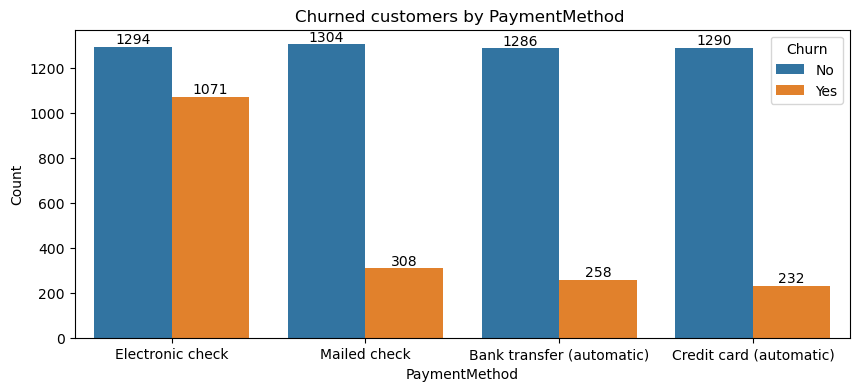

In [66]:
plt.figure(figsize= (10,4))
ax= sns.countplot(x = 'PaymentMethod',hue= 'Churn', data= df)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Churned customers by PaymentMethod ")
plt.xlabel("PaymentMethod")
plt.ylabel("Count")
plt.show()

***Electronic check users churn the most, while automatic bank transfer and credit card customers show the lowest churn rates.***

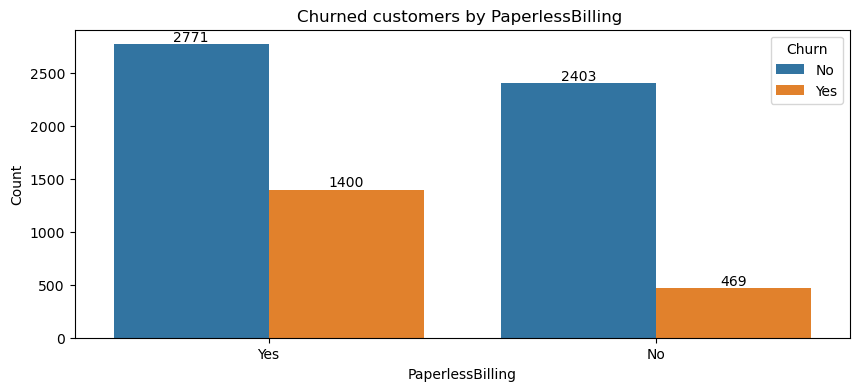

In [67]:
plt.figure(figsize= (10,4))
ax= sns.countplot(x = 'PaperlessBilling',hue= 'Churn', data= df)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Churned customers by PaperlessBilling ")
plt.xlabel("PaperlessBilling")
plt.ylabel("Count")
plt.show()

**Customers using paperless billing show higher churn, with 1400 leaving compared to 469 among non‑paperless users, highlighting a retention gap tied to billing preference.**

In [73]:
data1= df.groupby('Churn')['TotalCharges'].sum().reset_index()

C:\Users\uktiw\AppData\Local\Temp\ipykernel_6296\1344706270.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn', y='TotalCharges', data=data1, palette='Set2')


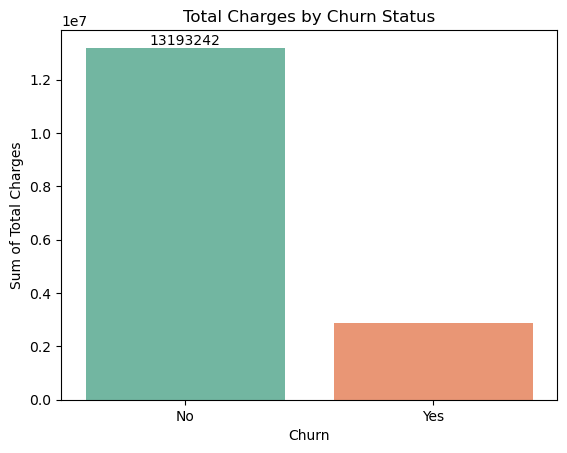

In [74]:
ax = sns.barplot(x='Churn', y='TotalCharges', data=data1, palette='Set2')
ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title("Total Charges by Churn Status")
plt.ylabel("Sum of Total Charges")
plt.show()

***Customers who stayed generated nearly five times the revenue of those who churned, underscoring the financial impact of retention.***

### How do MonthlyCharges and TotalCharges together influence Churn?

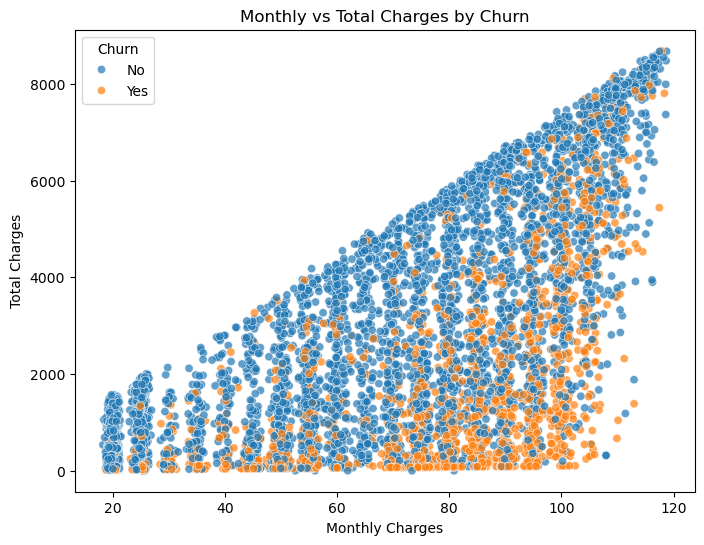

In [75]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, alpha=0.7)
plt.title("Monthly vs Total Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

***High monthly fees combined with short tenure drive churn, while long‑term customers balance charges and deliver the bulk of revenue.***

### Are churned customers concentrated in specific ranges of monthly vs. total charges?

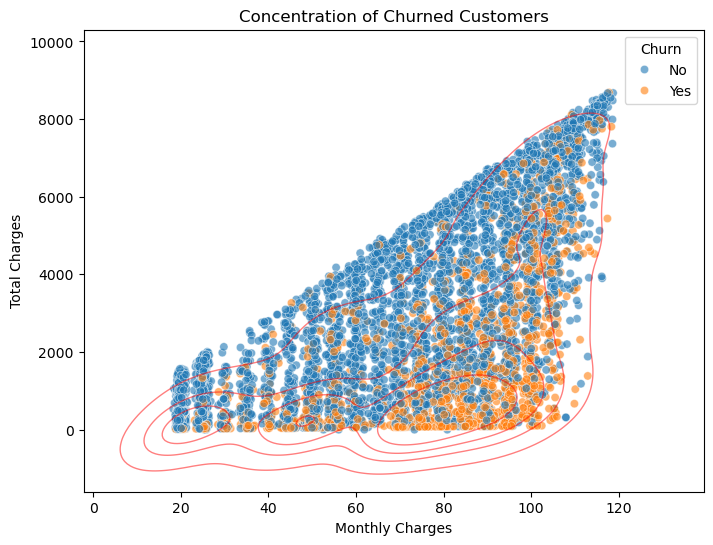

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, alpha=0.6)

# Add density contours for churned customers
sns.kdeplot(
    data=df[df['Churn']=='Yes'],
    x='MonthlyCharges', y='TotalCharges',
    levels=5, color='red', linewidths=1, alpha=0.5
)

plt.title("Concentration of Churned Customers")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

***Churn risk is highest among new customers facing high monthly fees, while long‑tenured customers remain stable across charge levels.***